#**Лабораторная работа 1: «Метод обратного распространения ошибки»**

---

##**Цели работы**
Цель — написать собственную реализацию полносвязной нейронной сети. Изучить математический аппарат, который стоит в основе работы нейронных сетей. Реализовать прямой проход и обратный, метод обратного распространения ошибки.

##**Задачи работы**
Выполнение лабораторной работы предполагает решение следующих задач:

Изучить общую схему работы метода обратного распространения ошибки с использованием стохастического градиентного спуска.
Вывести математические формулы для вычисления градиентов функции ошибки по параметрам нейронной сети и формул коррекции весов.
Загрузить набор данных MNIST, выполнить предобработку изображений и меток, если это необходимо.
Реализовать и протестировать метод обратного распространения ошибки для задачи классификации рукописных цифр из набора данных MNIST.


1.   Изучить общую схему работы метода обратного распространения ошибки с использованием стохастического градиентного спуска.
2.   Вывести математические формулы для вычисления градиентов функции ошибки по параметрам нейронной сети и формул коррекции весов.
3.   Загрузить набор данных MNIST и выполнить его предобработку.
4.   Реализовать и протестировать прямой и обратный проход для задачи классификации рукописных цифр из набора данных MNIST.


# **Конфигурация нейронной сети**

## 1. Входной слой
Содержит $w \times h$ нейронов, что соответствует разрешению одноканального изображения.  
Для набора MNIST это составляет $28 \times 28 = 784$ нейрона.

## 2. Выходной слой
Содержит $k$ нейронов, что соответствует количеству классов изображений.  
Для задачи классификации рукописных цифр MNIST — **10 классов**.

## 3. Скрытый слой
Содержит $s$ нейронов (параметр).

## 4. Параметры метода обучения:
- **Скорость обучения** (learning rate)
- **Размер пачки данных** (batch size)
- **Количество эпох**

## 5. Функции активации:
- На скрытом слое — функция **ReLU**
- На выходном слое — функция **softmax**
- Входной слой не содержит функции активации

## 6. Функция ошибки
**Кросс-энтропия**  
*Примечание: softmax вместе с кросс-энтропией упрощает вывод формул.*

## 7. Контрольные параметры для демонстрации работы нейронной сети:
- **Размер пачки данных:** от 8 до 64 изображений (в зависимости от доступного объема памяти)
- **Скорость обучения:** 0.1
- **Количество скрытых нейронов $s$:** 300
- **Количество эпох:** 20


Для начала скачаем MNIST, нормализуем его и приведем в вид массива NumPy.
Переведем y в формат one-hot encoding.
После этого разделим его на тренировочную и тестовую выборку:

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml

#dataset
mnist = fetch_openml('mnist_784', version=1)
x = np.array(mnist.data.astype(np.float32) / 255.0)
y = np.array(mnist.target.astype(np.int8))
y_one_hot = np.eye(10)[y]


x_train, x_test = x[:60000], x[60000:]
y_train, y_test = y[:60000], y[60000:]
y_one_hot_train, y_one_hot_test = y_one_hot[:60000], y_one_hot[60000:]



Покажем на картинке эту выборку

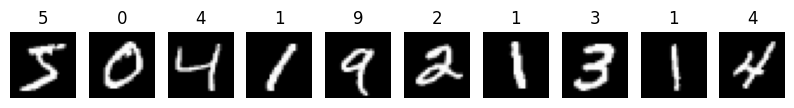

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    rshpd_im = x[i].reshape(28, 28)
    plt.imshow(rshpd_im, cmap='gray')
    plt.title(y[i])
    plt.axis('off')
plt.show()

Введём функцию нормализации градиента, которая будет использоваться в дальнейшем коде. Если норма градиента больше 1.0, тогда приводим его к единичной норме:

In [ ]:
def norm_grad(grad, max_grad=1.0):
	grad_norm = np.linalg.norm(grad)
	if grad_norm > max_grad:
		grad = (grad / grad_norm) * max_grad
	return grad


Теперь напишем реализацию слоев нашей нейронной сети.
Ниже представлены реализации слоев функции активации ReLU и обычного линейного слоя. Все слои реализованы как классы. Каждый из них имеет конструктор, метод "\_\_call\_\_", который позволяет пользоваться объектом как функцией.
Так же реализованы методы forward, который сохраняет внутрь класса поданное на вход значение, вычисляет математическую функцию и реализуют прямой проход по нейронной сети, и backward, который считает градиент для параметров этого слоя и градиент для обратного прохода, который передается на вход предыдущему слою.
Слой Linear содержит метод step, который обновляет его параметры, на основе градиентов, подсчитанных в методе backward:

In [ ]:
class ReLU:
    def __init__(self):
        # Обычный ReLU не имеет параметров
        pass

    def __call__(self, x):
        return self.forward(x)

    def forward(self, x):
        self.x = x  # Сохраняем для backward pass
        return np.maximum(0, x)

    def backward(self, grad):
        # Создаем маску: 1 где x > 0, 0 иначе
        mask = (self.x > 0).astype(np.float32)
        return grad * mask

class Linear:

  '''
	def __init__(self, n_inp, n_out):
		n = 6**0.5 / (n_inp+n_out)**0.5
		self.w = np.random.uniform(-n, n, (n_inp, n_out))
		n = 6**0.5 / (1+n_out)**0.5
		self.b = np.random.uniform(-n, n, (1, n_out))

  '''

  def __init__(self, n_inp, n_out, use_bias=True):
    # Kaiming инициализация
    # std = sqrt(2 / n_inp) для сохранения дисперсии
    std = np.sqrt(2.0 / n_inp)

    # Инициализируем веса нормальным распределением
    self.w = np.random.randn(n_inp, n_out) * std
    self.b = np.zeros((1, n_out))

  def __call__(self, x):
    return self.forward(x)

  def forward(self, x):
    self.x = x
    return x @ self.w + self.b

  def backward(self, grad):
    self.w_grad = self.x.T @ grad
    self.b_grad = np.sum(grad, axis=0, keepdims=True)
    x_grad = grad @ self.w.T

    return x_grad

  def step(self, lr=0.01):
    self.w -= lr * norm_grad(self.w_grad)
    self.b -= lr * norm_grad(self.b_grad)

Далее реализуем класс Sequential.
Это контейнер, который объединяет несколько слоёв нейронной сети в последовательную цепочку для удобного управления вычислениями. Метод forward осуществляет прямой проход и вызывает одноименный метод для всех слоев, метод backward осуществляет обратный проход и вызывает одноименный метод для всех слоев в обратном порядке. Метод step вызывает одноименный метод для всех слоев.

In [ ]:
class Sequential:
	def __init__(self, layers):
		self.layers = layers

	def __call__(self, x):
		return self.forward(x)

	def forward(self, x):
		for layer in self.layers:
			x = layer.forward(x)
		return x

	def backward(self, grad):
		for layer in reversed(self.layers):
			grad = layer.backward(grad)
		return grad

	def step(self, lr=0.01):
		for layer in self.layers:
			if hasattr(layer, 'step'):
				layer.step(lr=lr)

Далее напишем функцию, реализующую softmax и кроссэнтропию:

In [ ]:
def softmax_cross_entropy_loss(logits, labels, eps=1e-8):
    """
    Упрощенная версия: всегда использует reduction='mean'

    Args:
        logits: Сырые выходы сети, shape (batch_size, num_classes)
        labels: Целевые метки (индексы или one-hot)
        eps: Малое число для избежания log(0)

    Returns:
        loss: Скалярное значение loss
        grad: Градиент по логитам, shape (batch_size, num_classes)
    """
    batch_size = logits.shape[0]

    # Преобразуем метки в one-hot если нужно

    labels_onehot = labels

    # Стабильный softmax
    logits_max = np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits - logits_max)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    # Cross-entropy loss
    probs_clipped = np.clip(probs, eps, 1 - eps)
    log_probs = np.log(probs_clipped)
    loss = -np.mean(np.sum(labels_onehot * log_probs, axis=1))

    # Градиент
    grad = (probs - labels_onehot) / batch_size

    return loss, grad


Теперь обучим нейронную сеть на тренировочной выборке:

In [ ]:
#learning rate
lr = 0.1
#количество эпох
steps = 20
#размер батча
batch_size = 64


#модель
model = Sequential([
	Linear(784, 300),
	ReLU(),
	Linear(300, 10),
])


#training
for i in range(steps):
	epoch_loss = 0
	permutation = np.random.permutation(x.shape[0])
	x_shuffled = x[permutation]
	y_shuffled = y_one_hot[permutation]

	for start in range(0, x.shape[0], batch_size):
		end = start + batch_size
		x_batch = x_shuffled[start:end]
		y_batch = y_shuffled[start:end]

		res = model(x_batch)
		loss, grad = softmax_cross_entropy_loss(res, y_batch)
		epoch_loss += loss

		model.backward(grad)
		model.step(lr)

	print(f'Step {i+1}, Loss: {epoch_loss}')


#test
predicted_labels = np.argmax(model(x_train), axis=1)
correct_predictions = np.sum(predicted_labels == y_train)
total_samples = x_train.shape[0]
accuracy = correct_predictions / total_samples
print(f'Правильных ответов: {correct_predictions} из {total_samples}')
print(f'Точность: {accuracy * 100:.2f}%')

Step 1, Loss: 369.90817343237217
Step 2, Loss: 186.01526485647256
Step 3, Loss: 135.25350143624763
Step 4, Loss: 107.6941567003655
Step 5, Loss: 88.83402716221147
Step 6, Loss: 76.28606840024095
Step 7, Loss: 65.74464305923713
Step 8, Loss: 58.12385047854379
Step 9, Loss: 51.60970786454041
Step 10, Loss: 45.89180901010319
Step 11, Loss: 41.613604076033724
Step 12, Loss: 37.34494141890648
Step 13, Loss: 33.783755652997556
Step 14, Loss: 30.868342910758862
Step 15, Loss: 27.523573873983555
Step 16, Loss: 25.397168207918778
Step 17, Loss: 23.046472717024304
Step 18, Loss: 21.16139365725355
Step 19, Loss: 19.375370135299576
Step 20, Loss: 17.690464780002916
Правильных ответов: 59881 из 60000
Точность: 99.80%


Теперь проверим нейронную сеть на тестовой выборке:

In [ ]:
predicted_labels = np.argmax(model(x_test), axis=1)
correct_predictions = np.sum(predicted_labels == y_test)
total_samples = x_test.shape[0]
accuracy = correct_predictions / total_samples
print(f'Правильных ответов: {correct_predictions} из {total_samples}')
print(f'Точность: {accuracy * 100:.2f}%')

Правильных ответов: 9983 из 10000
Точность: 99.83%
